<a href="https://colab.research.google.com/github/adityahadagalle/Machine_learning_projects/blob/main/firsttry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CarPrice_Assignment.csv to CarPrice_Assignment.csv


In [ ]:
import pandas as pd

df = pd.read_csv("CarPrice_Assignment.csv")
df=df.drop(columns=["car_ID","symboling","enginelocation","stroke","fuelsystem",'carheight',"compressionratio","peakrpm"])
df

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,wheelbase,carlength,carwidth,curbweight,enginetype,cylindernumber,enginesize,boreratio,horsepower,citympg,highwaympg,price
0,alfa-romero giulia,gas,std,two,convertible,rwd,88.6,168.8,64.1,2548,dohc,four,130,3.47,111,21,27,13495.0
1,alfa-romero stelvio,gas,std,two,convertible,rwd,88.6,168.8,64.1,2548,dohc,four,130,3.47,111,21,27,16500.0
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,94.5,171.2,65.5,2823,ohcv,six,152,2.68,154,19,26,16500.0
3,audi 100 ls,gas,std,four,sedan,fwd,99.8,176.6,66.2,2337,ohc,four,109,3.19,102,24,30,13950.0
4,audi 100ls,gas,std,four,sedan,4wd,99.4,176.6,66.4,2824,ohc,five,136,3.19,115,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,volvo 145e (sw),gas,std,four,sedan,rwd,109.1,188.8,68.9,2952,ohc,four,141,3.78,114,23,28,16845.0
201,volvo 144ea,gas,turbo,four,sedan,rwd,109.1,188.8,68.8,3049,ohc,four,141,3.78,160,19,25,19045.0
202,volvo 244dl,gas,std,four,sedan,rwd,109.1,188.8,68.9,3012,ohcv,six,173,3.58,134,18,23,21485.0
203,volvo 246,diesel,turbo,four,sedan,rwd,109.1,188.8,68.9,3217,ohc,six,145,3.01,106,26,27,22470.0


In [ ]:
if "CarName" in df.columns:
    df["brand"] = df["CarName"].astype(str).str.split().str[0].str.lower()
    df.drop("CarName", axis=1, inplace=True)
    # quick fixes (common typos in this dataset)
    df["brand"] = df["brand"].replace({
        "vw":"volkswagen","vokswagen":"volkswagen",
        "porcshce":"porsche","toyouta":"toyota"
    })

In [ ]:
df

,fueltype,aspiration,doornumber,carbody,drivewheel,wheelbase,carlength,carwidth,curbweight,enginetype,cylindernumber,enginesize,boreratio,horsepower,citympg,highwaympg,price,brand
0,gas,std,two,convertible,rwd,88.6,168.8,64.1,2548,dohc,four,130,3.47,111,21,27,13495.0,alfa-romero
1,gas,std,two,convertible,rwd,88.6,168.8,64.1,2548,dohc,four,130,3.47,111,21,27,16500.0,alfa-romero
2,gas,std,two,hatchback,rwd,94.5,171.2,65.5,2823,ohcv,six,152,2.68,154,19,26,16500.0,alfa-romero
3,gas,std,four,sedan,fwd,99.8,176.6,66.2,2337,ohc,four,109,3.19,102,24,30,13950.0,audi
4,gas,std,four,sedan,4wd,99.4,176.6,66.4,2824,ohc,five,136,3.19,115,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,gas,std,four,sedan,rwd,109.1,188.8,68.9,2952,ohc,four,141,3.78,114,23,28,16845.0,volvo
201,gas,turbo,four,sedan,rwd,109.1,188.8,68.8,3049,ohc,four,141,3.78,160,19,25,19045.0,volvo
202,gas,std,four,sedan,rwd,109.1,188.8,68.9,3012,ohcv,six,173,3.58,134,18,23,21485.0,volvo
203,diesel,turbo,four,sedan,rwd,109.1,188.8,68.9,3217,ohc,six,145,3.01,106,26,27,22470.0,volvo


In [ ]:
df["brand"].value_counts()

,count
brand,
toyota,32
nissan,18
mazda,15
mitsubishi,13
honda,13
volkswagen,12
subaru,12
volvo,11
peugeot,11


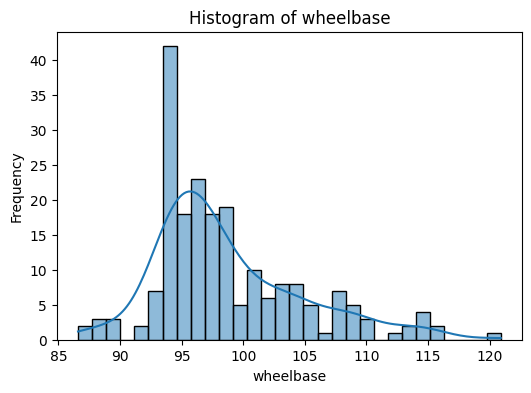

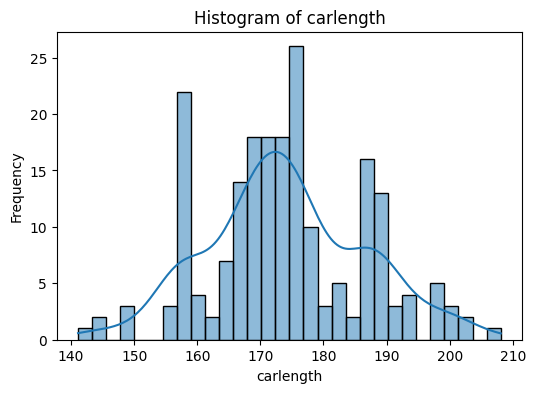

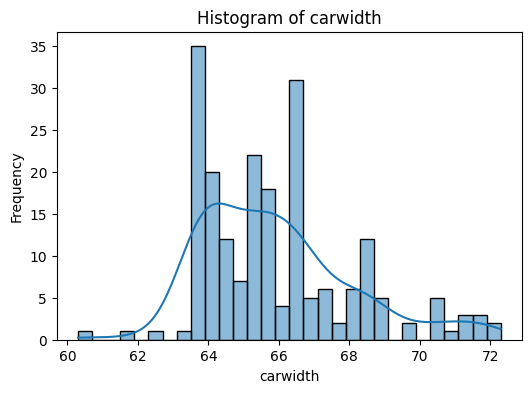

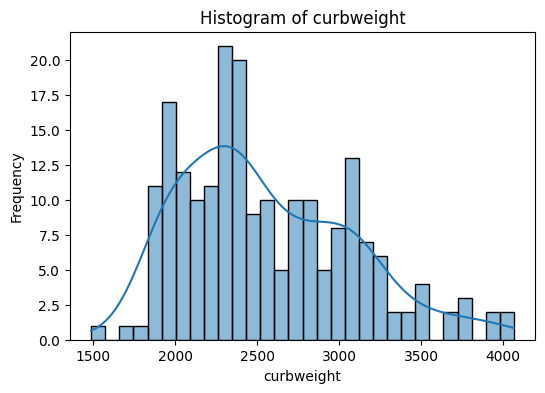

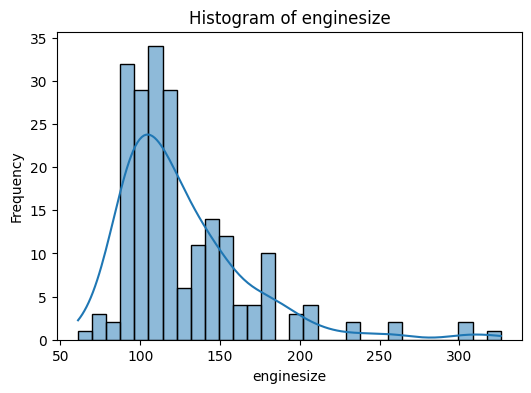

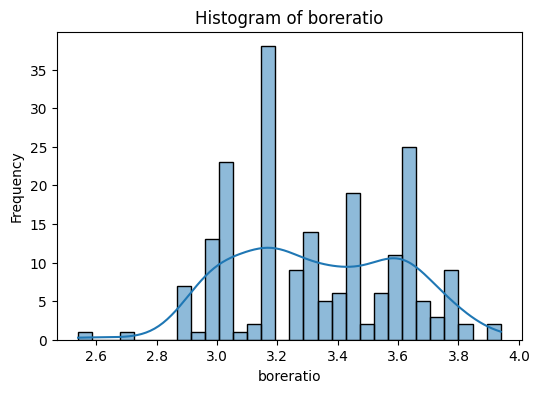

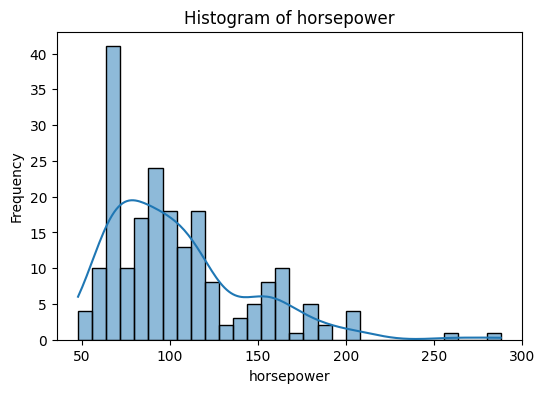

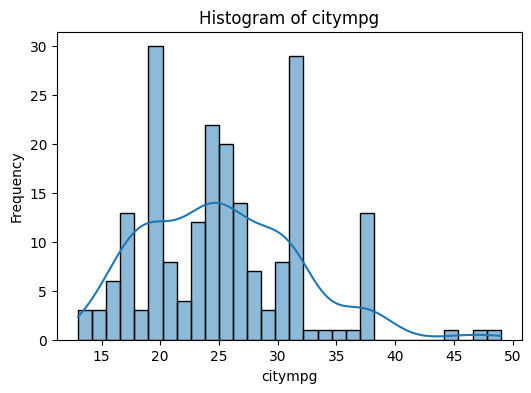

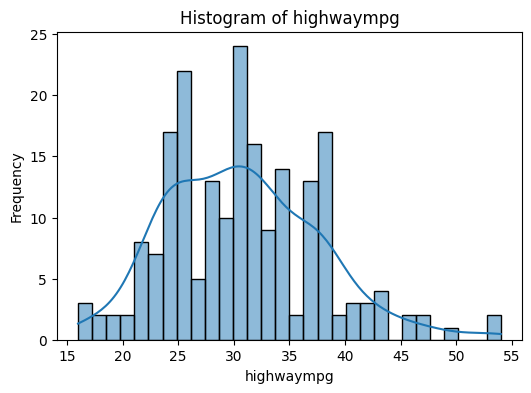

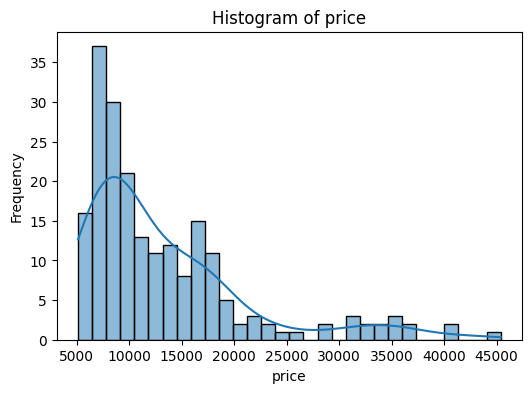

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num = df.select_dtypes(include="number")

for col in num.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()



**checking skewness**

In [ ]:
df.select_dtypes(include="number").skew().sort_values(ascending=False)


,0
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997
carlength,0.155954
boreratio,0.020156


In [ ]:
df.shape

(205, 18)

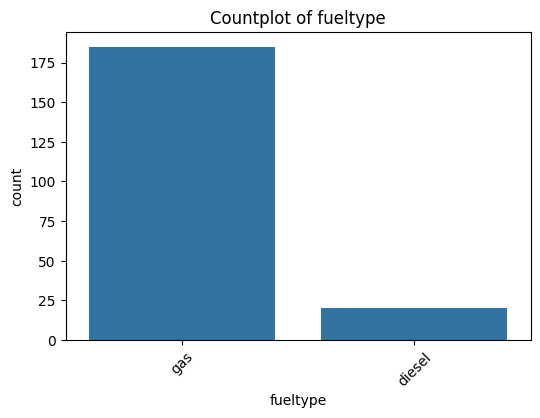

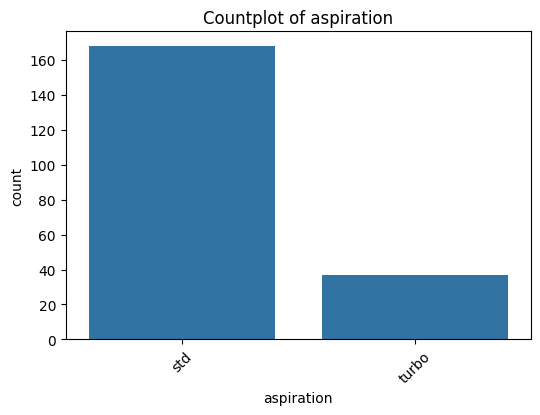

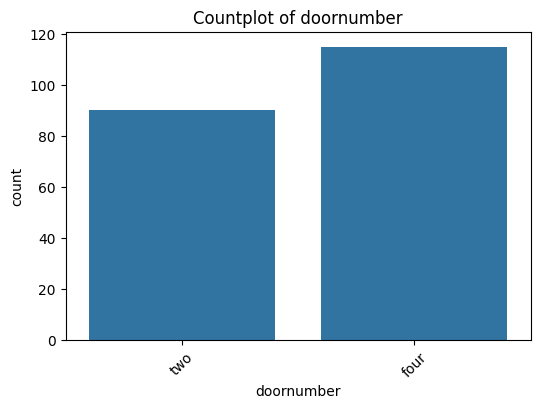

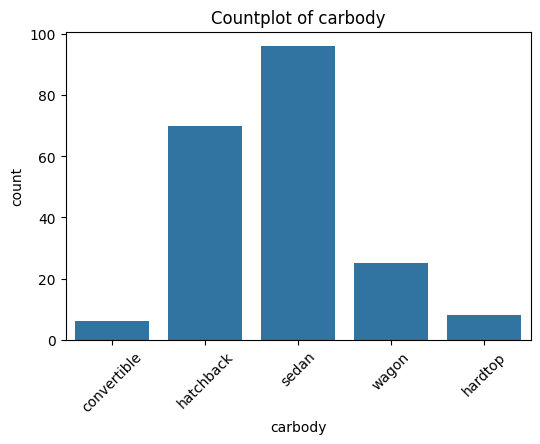

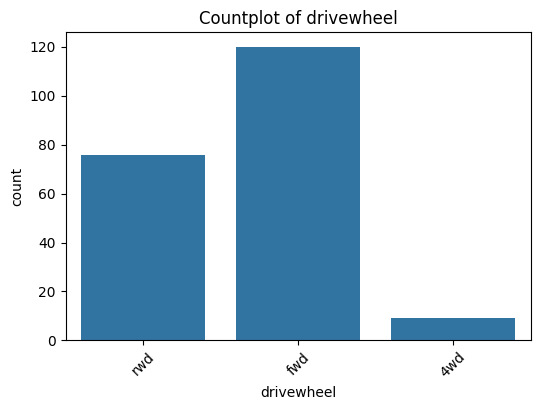

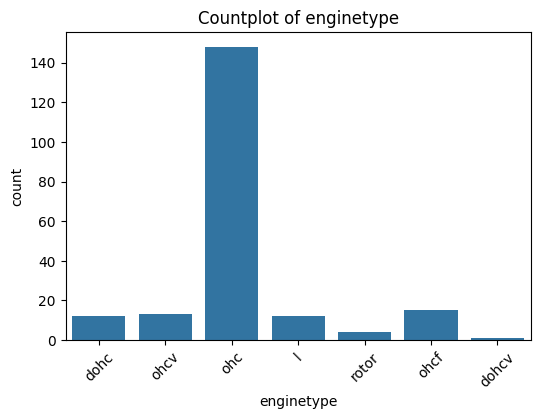

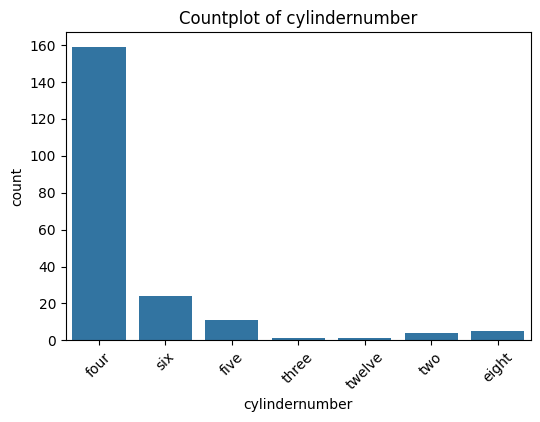

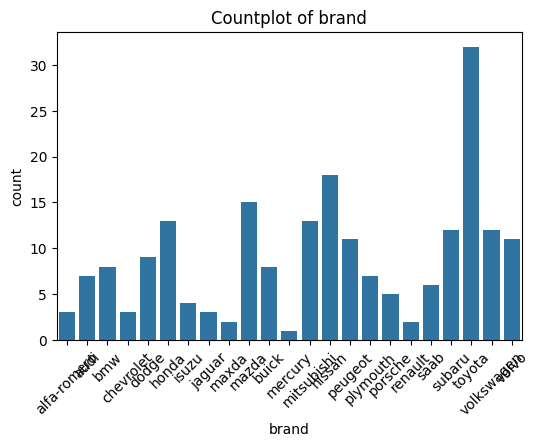

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cat = df.select_dtypes(include='object')

for col in cat.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()


**checking multicolineartry**

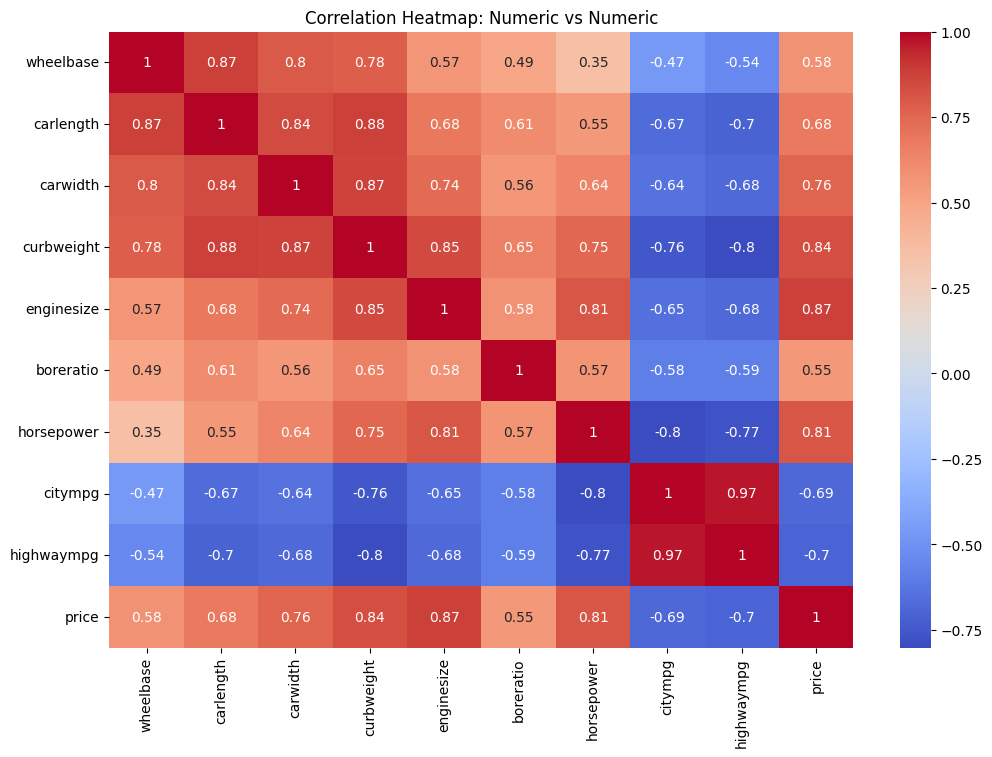

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap: Numeric vs Numeric")
plt.show()


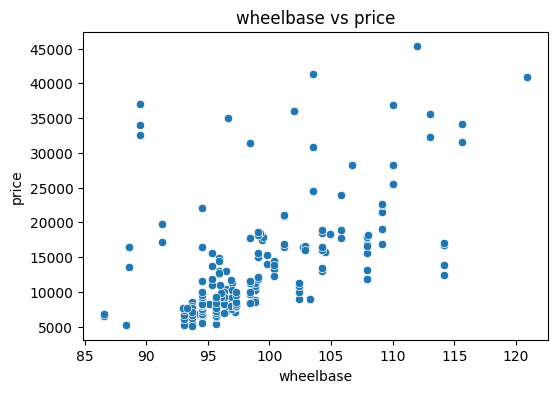

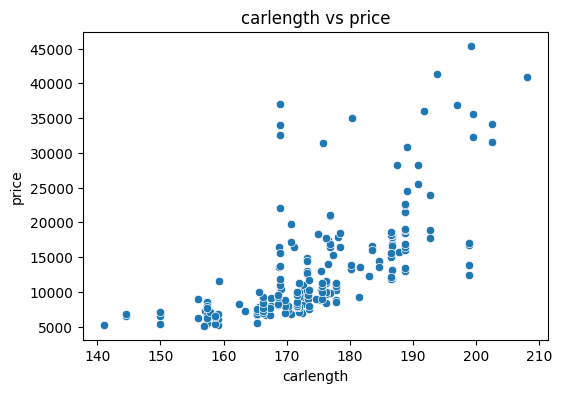

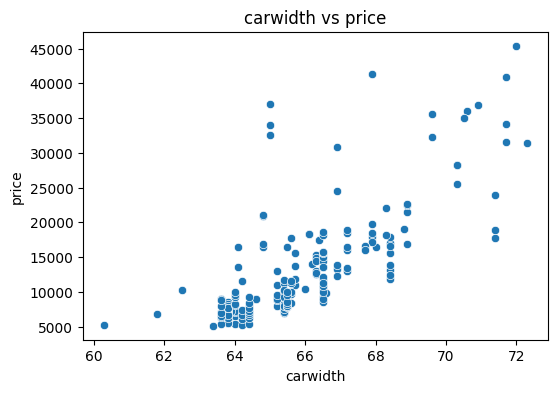

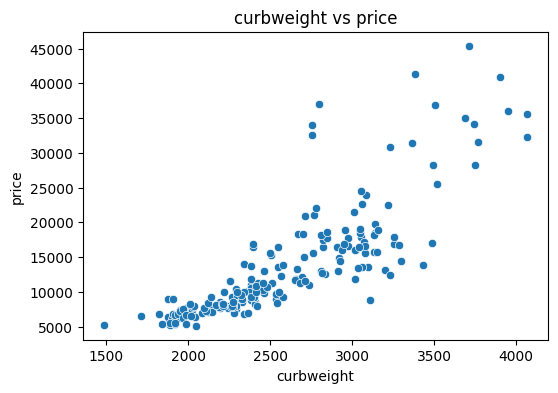

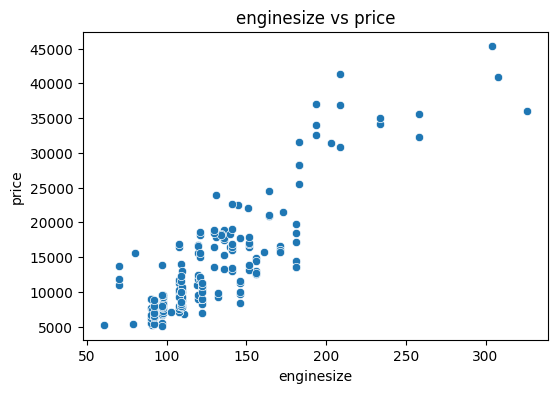

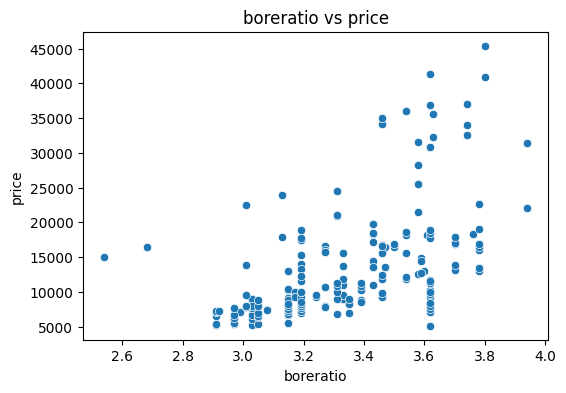

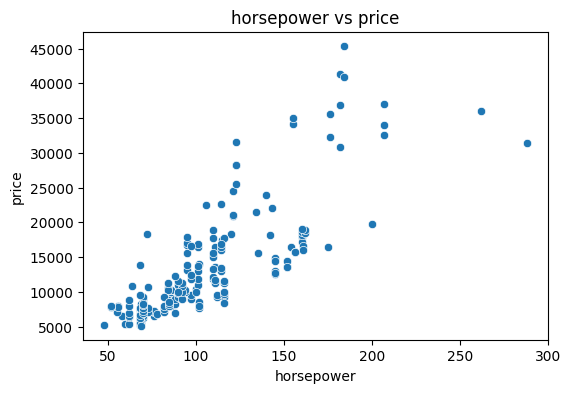

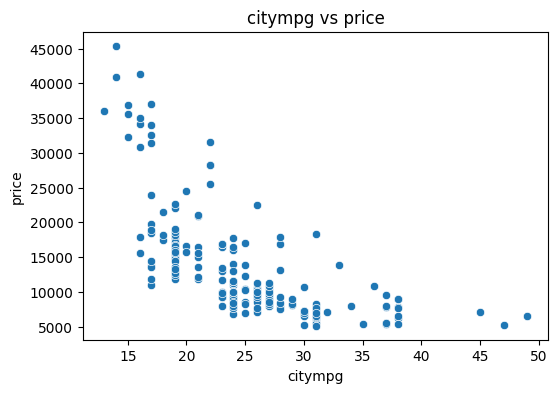

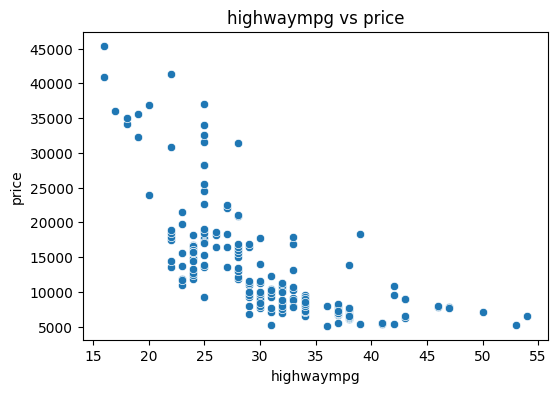

In [ ]:
target = "price"   # change if your target is different

for col in num.columns:
    if col != target:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()


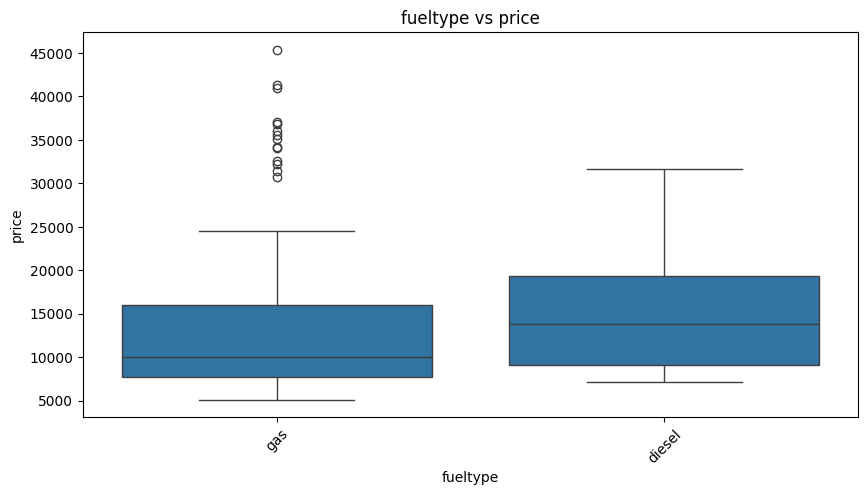

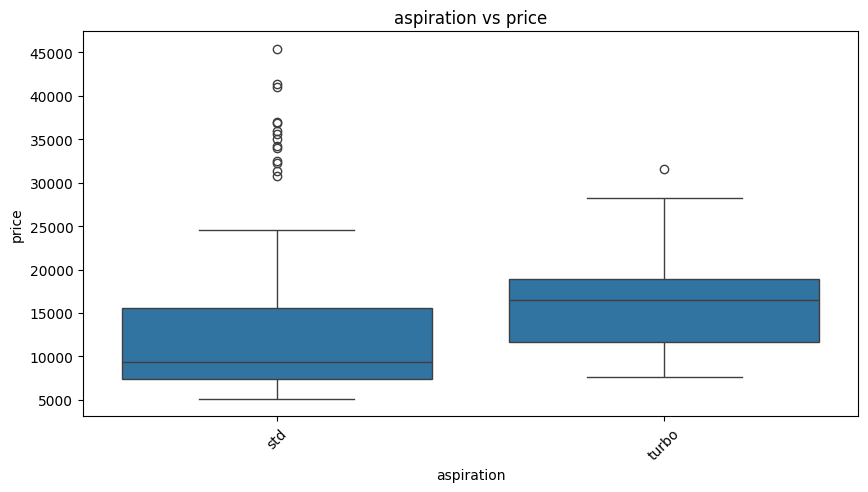

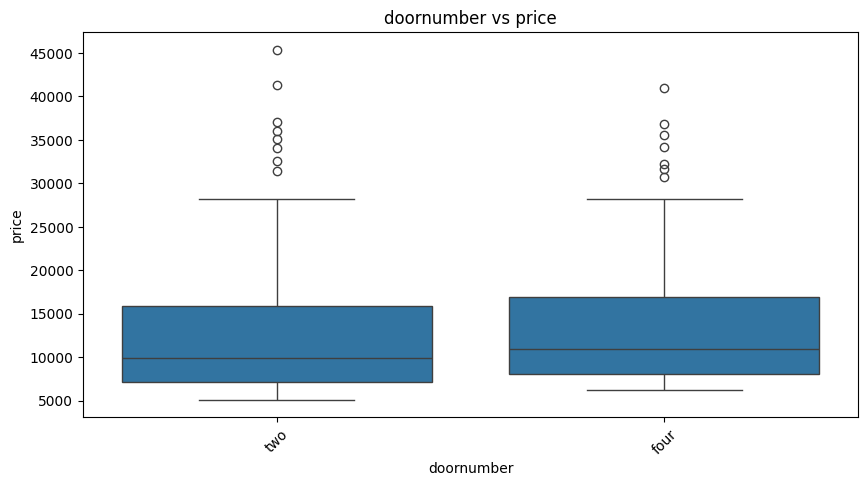

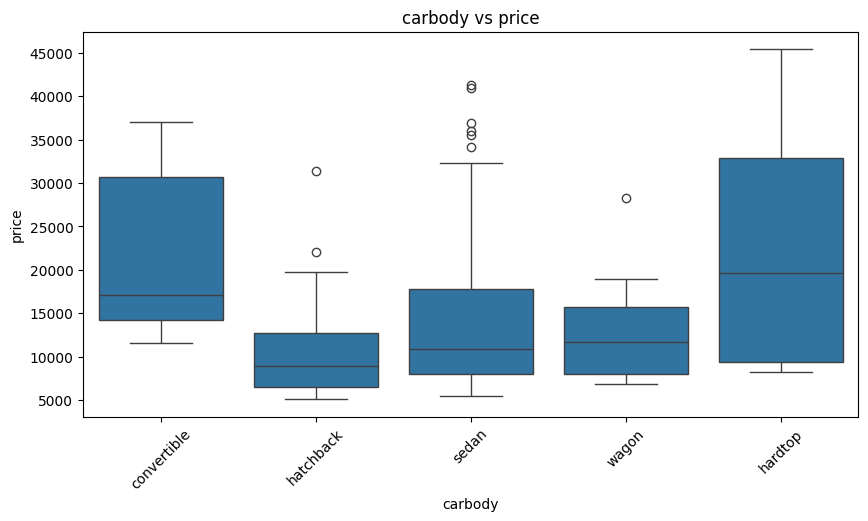

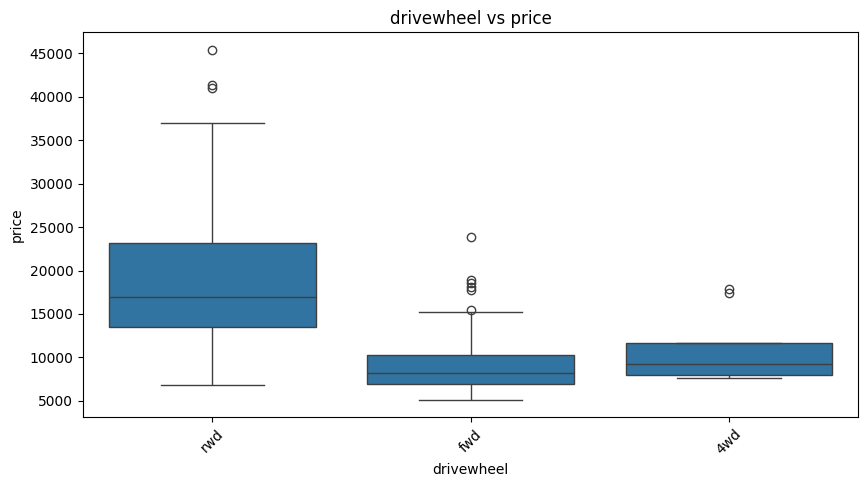

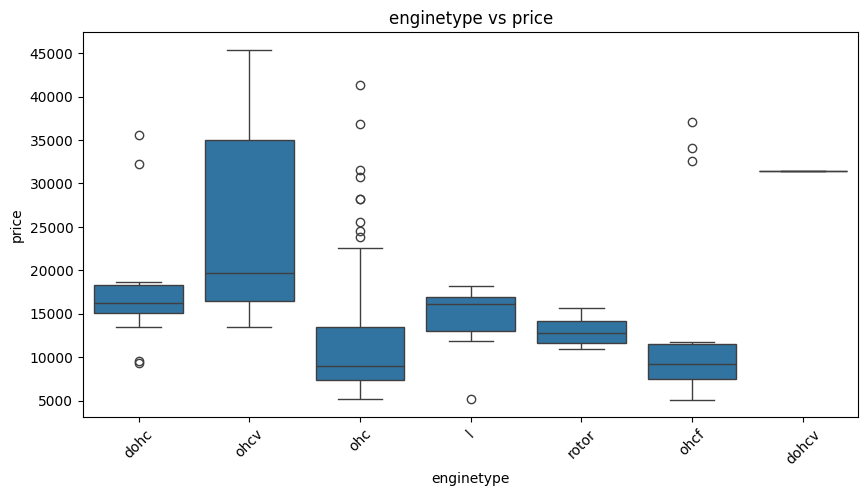

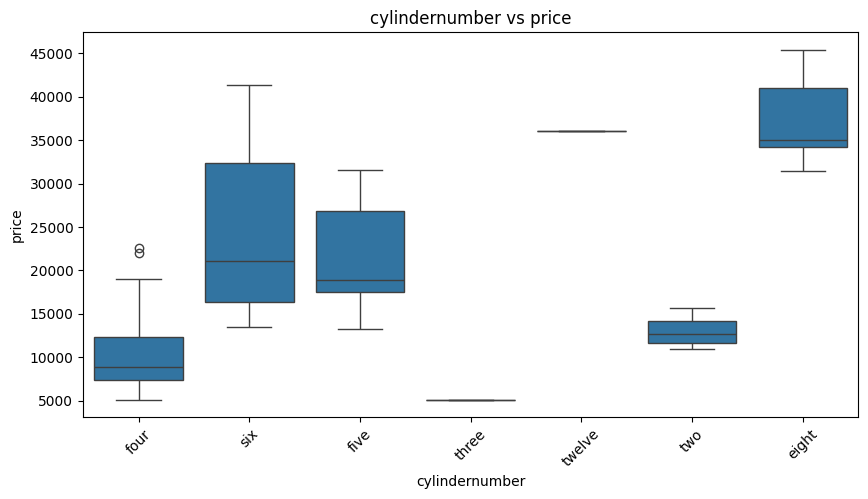

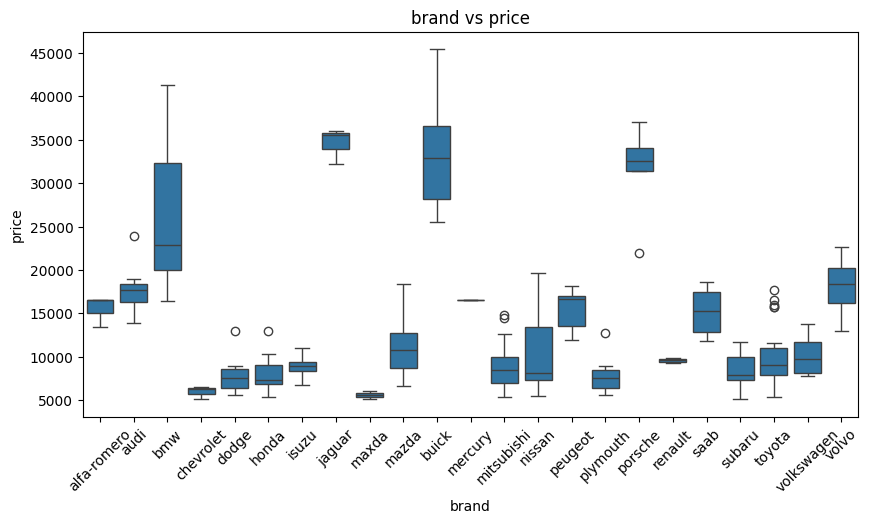

In [ ]:
cat = df.select_dtypes(include='object')
import seaborn as sns
import matplotlib.pyplot as plt
target = "price"

for col in cat.columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()


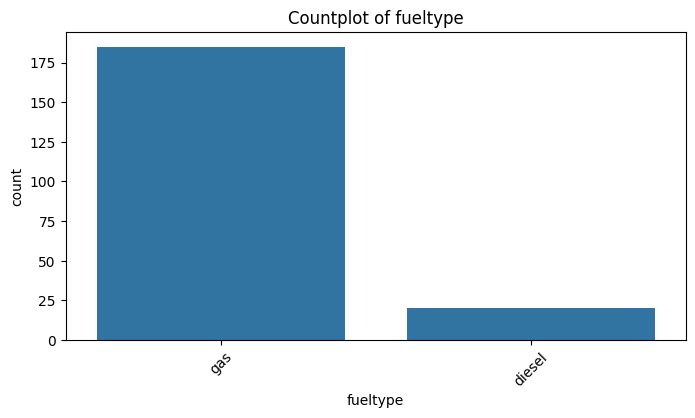

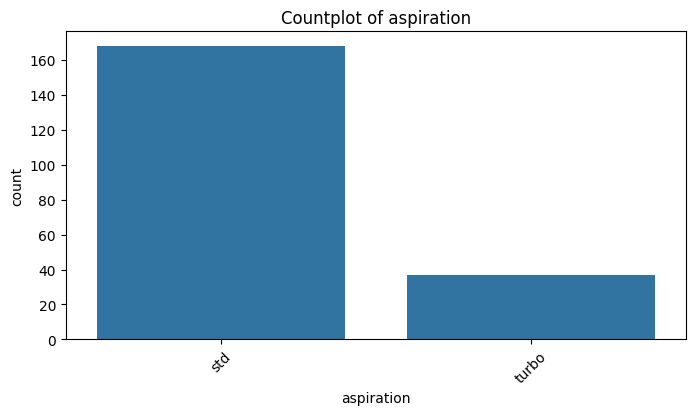

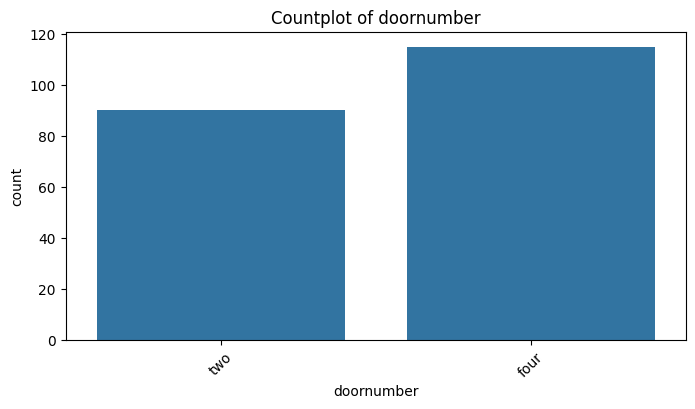

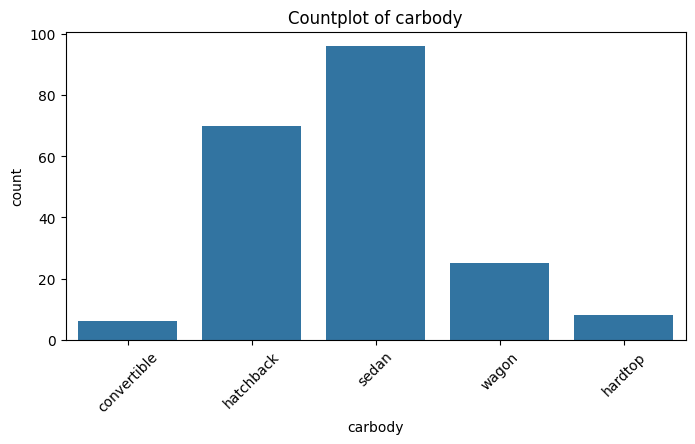

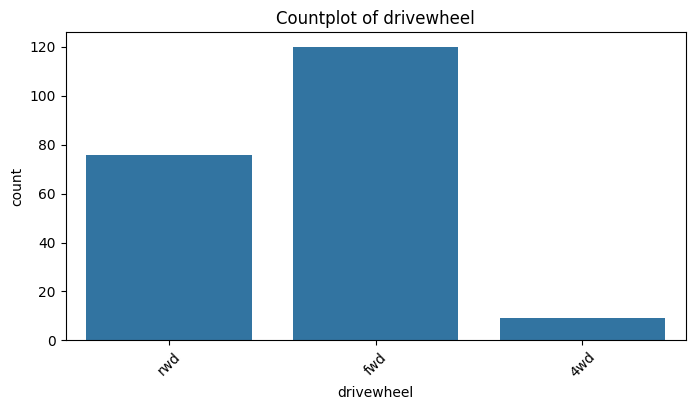

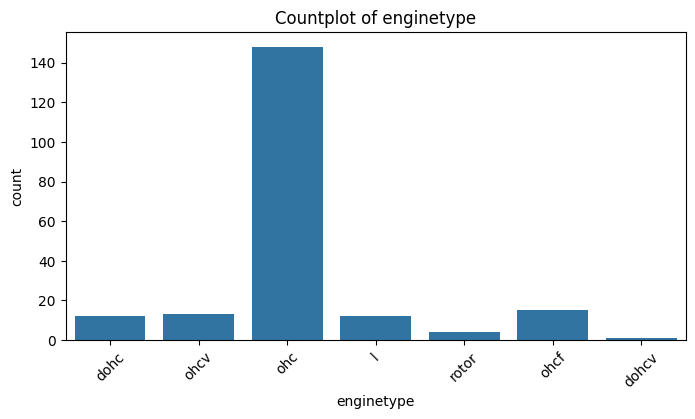

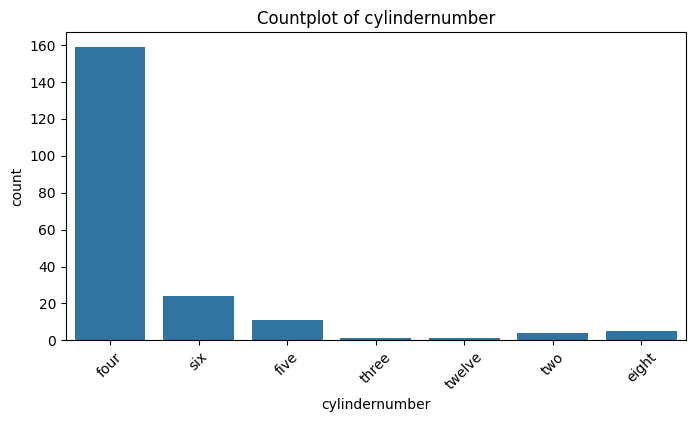

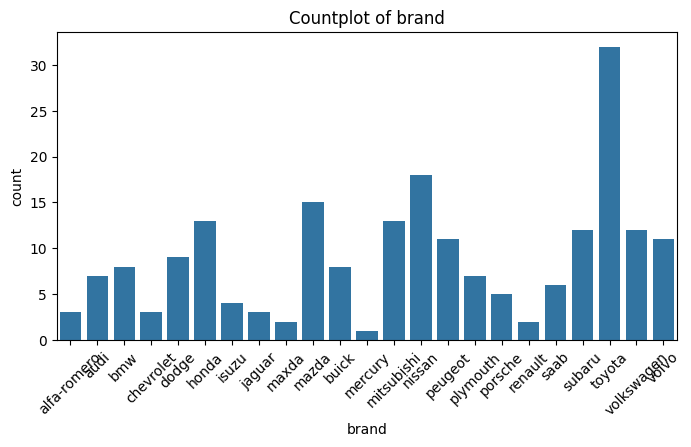

In [ ]:
import math

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()


**i should merge values if they are less than 5%
**if values are less than 5 ,it is not good for target encoding


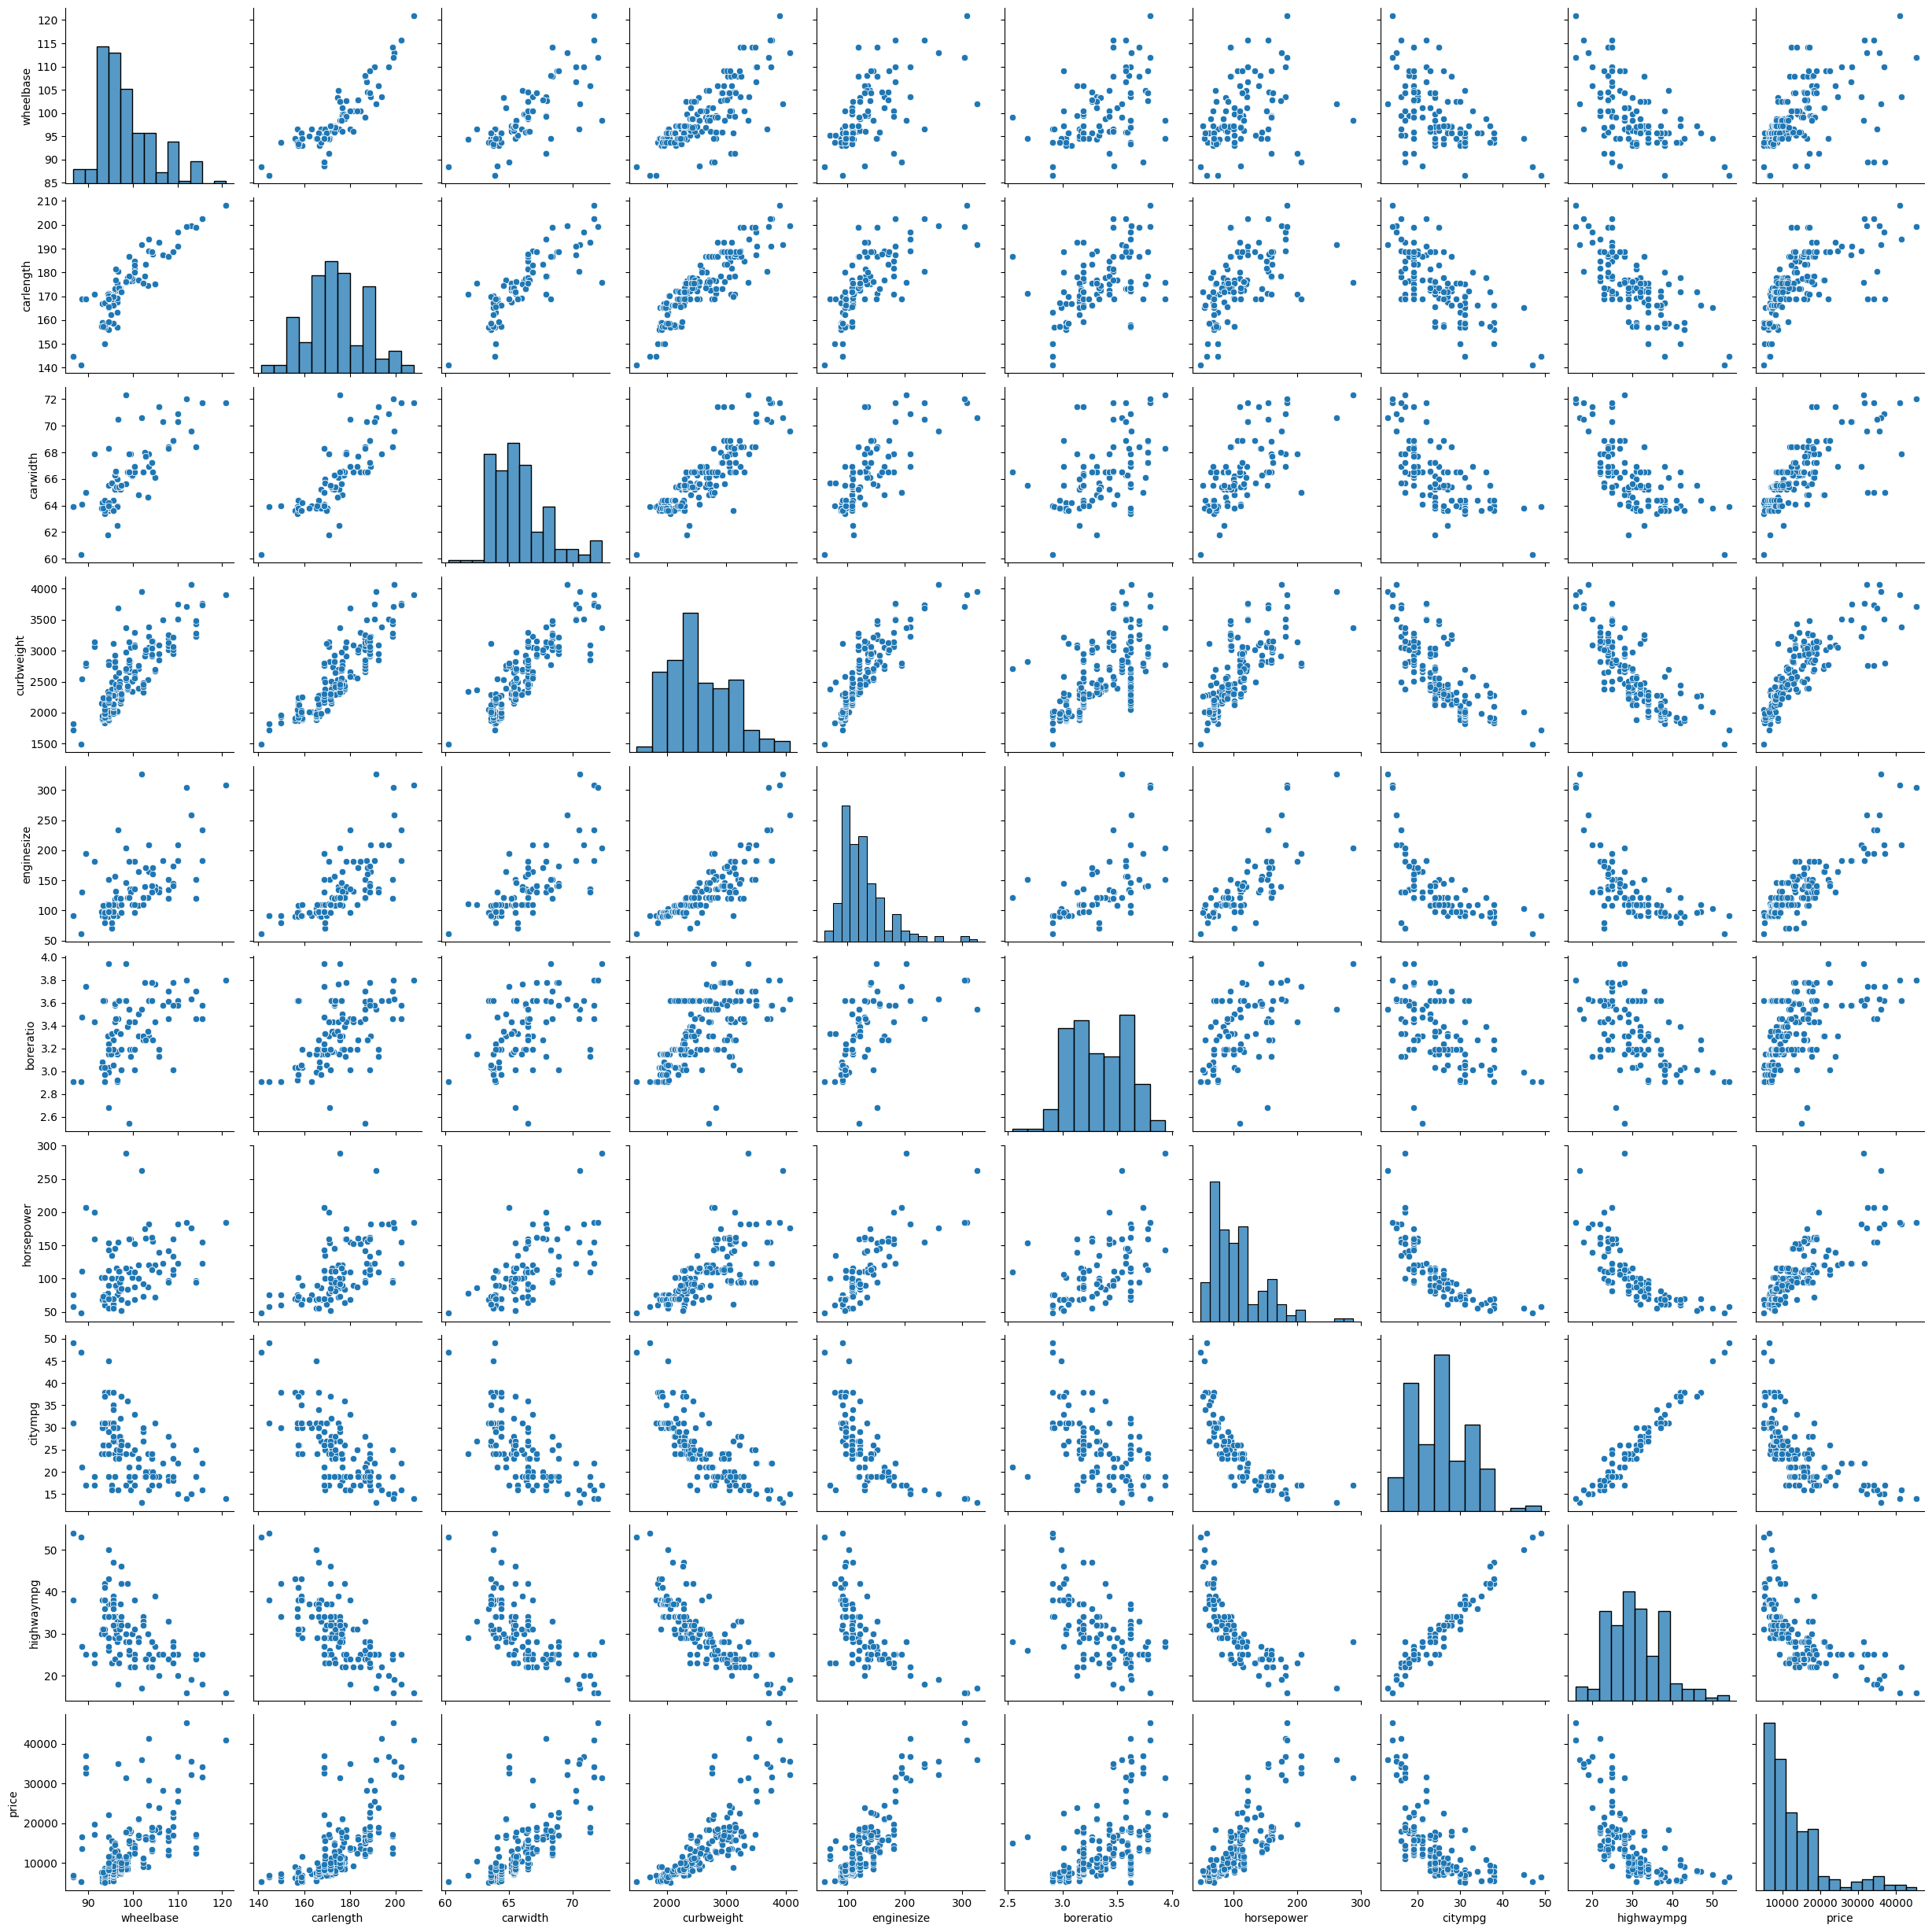

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num = df.select_dtypes(include="number")

sns.pairplot(num)
plt.show()


In [ ]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, title="Car Dataset Profile Report", explorative=True)
# profile.to_file("car_report.html")


In [ ]:
df.isnull().sum()


,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
wheelbase,0
carlength,0
carwidth,0
curbweight,0
enginetype,0


In [ ]:
num = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
if 'price' in num:
  num_cols = [c for c in num if c != 'price']
else:
  num_cols = num.copy()


# Impute
for c in num_cols:
  if df[c].isnull().any():
    df[c].fillna(df[c].median(), inplace=True)
for c in cat:
  if df[c].isnull().any():
    df[c].fillna(df[c].mode().iloc[0], inplace=True)

In [ ]:
skew_values = df[num].skew().sort_values(ascending=False)
print('\nSkewness values:')
print(skew_values)


Skewness values:
enginesize    1.947655
price         1.777678
horsepower    1.405310
wheelbase     1.050214
carwidth      0.904003
curbweight    0.681398
citympg       0.663704
highwaympg    0.539997
carlength     0.155954
boreratio     0.020156
dtype: float64


In [ ]:
high_skew = skew_values[skew_values.abs() > 1].index.tolist()
moderate_skew = skew_values[(skew_values.abs() > 0.5) & (skew_values.abs() <= 1)].index.tolist()
print('\nHigh skew (>1):', high_skew)

print('Moderate skew (0.5-1):', moderate_skew)


High skew (>1): ['enginesize', 'price', 'horsepower', 'wheelbase']
Moderate skew (0.5-1): ['carwidth', 'curbweight', 'citympg', 'highwaympg']


In [ ]:
import numpy as np
for col in high_skew:
  if col != 'price':
    df[col] = np.log1p(df[col])
    print(f"Applied log1p transform to {col}")

Applied log1p transform to enginesize
Applied log1p transform to horsepower
Applied log1p transform to wheelbase


In [ ]:
skew_after = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print('\nSkewness after transforms:')
print(skew_after)


Skewness after transforms:
price         1.777678
carwidth      0.904003
wheelbase     0.885024
enginesize    0.864706
curbweight    0.681398
citympg       0.663704
highwaympg    0.539997
horsepower    0.489938
carlength     0.155954
boreratio     0.020156
dtype: float64


In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
from sklearn.tree import DecisionTreeRegressor
cat_cols = df.select_dtypes(include="object").columns.tolist()
target = "price"

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

# Train-test split BEFORE any encoding to avoid leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
ohe_cols = [c for c in cat_cols if X_train[c].nunique() <= 15]
te_cols = [c for c in cat_cols if X_train[c].nunique() > 15]

print("OHE Columns:", ohe_cols)
print("Target Encode Columns:", te_cols)

OHE Columns: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginetype', 'cylindernumber']
Target Encode Columns: ['brand']


In [ ]:
# ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# X_train_ohe = pd.DataFrame(
#     ohe.fit_transform(X_train[ohe_cols]),
#     columns=ohe.get_feature_names_out(ohe_cols),
#     index=X_train.index
# )

In [ ]:
# X_test_ohe = pd.DataFrame(
#     ohe.transform(X_test[ohe_cols]),
#     columns=ohe.get_feature_names_out(ohe_cols),
#     index=X_test.index
# )

In [ ]:
te = ce.TargetEncoder(cols=te_cols)

X_train_te = te.fit_transform(X_train[te_cols], y_train)
X_test_te = te.transform(X_test[te_cols])

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import category_encoders as ce
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [ ]:
pip install category_encoders


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), ohe_cols),
        ("te", ce.TargetEncoder(cols=te_cols), te_cols)
    ],
    remainder="drop"
)
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("lr", RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42))
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['wheelbase', 'carlength',
                                                   'carwidth', 'curbweight',
                                                   'enginesize', 'boreratio',
                                                   'horsepower', 'citympg',
                                                   'highwaympg']),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['fueltype', 'aspiration',
                                                   'doornumber', 'carbody',
                                                   'drivewheel', 'enginetype',
                                                   'cylindernumber']),
                                                 ('te',
                                                  TargetEncoder(cols=['brand']),
                                                  ['brand'])])),
                ('lr',
                 RandomForestRegressor(max_depth=15, n_estimators=300,
                                       random_state=42))])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))


MAE: 1448.324485094851
RMSE: 2087.7719877046375
R2: 0.9447862950977792


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))


CV R2 scores: [ 0.76055421  0.83042413 -0.61120167  0.90071146  0.72005693]
Mean CV R2: 0.5201090125856659


In [ ]:
# MAE: 1482.5886300813006
# RMSE: 2118.569588563164
# R2: 0.9431453192835627

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Run 5-fold CV directly on the pipeline
scores = cross_val_score(
    model,  # <--- your pipeline here
    X,         # full dataset
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1  # optional: use all CPU cores
)

print("R2 scores:", scores)
print("Mean R2:", np.mean(scores))


R2 scores: [ 0.76055421  0.83042413 -0.61120167  0.90071146  0.72005693]
Mean R2: 0.5201090125856659
